In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
np.warnings = warnings

import torch
import random
import math
import sys
sys.path.append("../..")  # Add parent directory to path
sys.path.append("../../../..")
from simple_synth import SimpleSynth
import scipy
import matplotlib
import matplotlib.pyplot as plt


tensor([0.0620, 0.3239, 0.2681, 0.2268, 0.0917, 0.0274])
Iteration 1/20, Current best: 0.5367, 


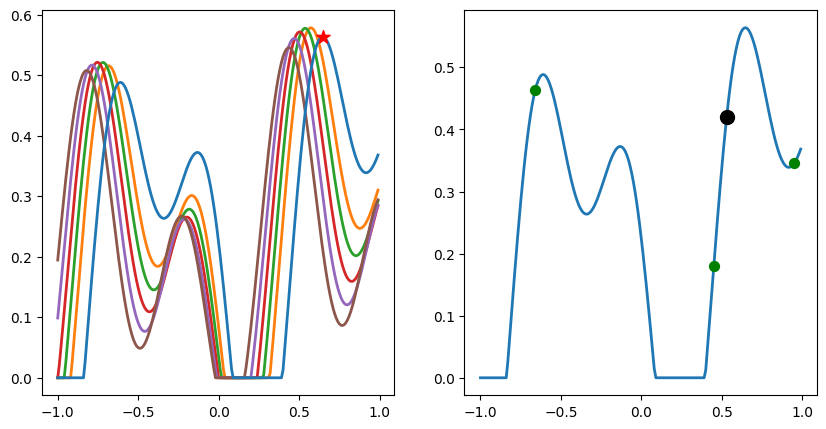

tensor([0.0897, 0.2425, 0.1878, 0.1888, 0.1857, 0.1054])
Iteration 2/20, Current best: 0.5367, 


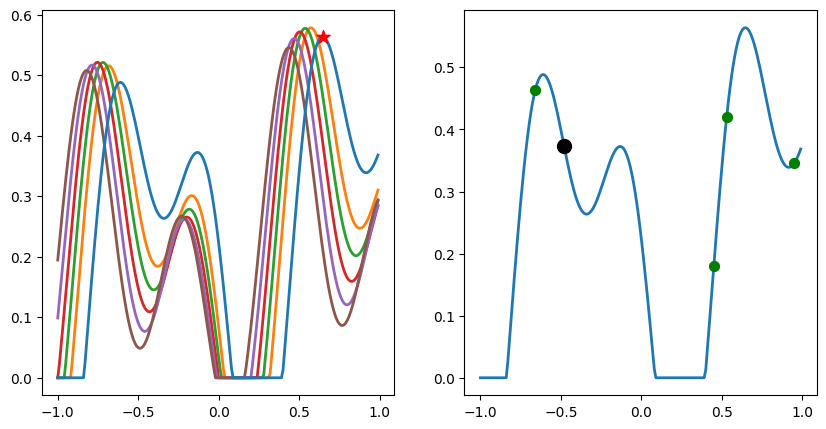

tensor([0.1411, 0.2741, 0.1927, 0.1755, 0.1523, 0.0644])
Iteration 3/20, Current best: 0.5367, 


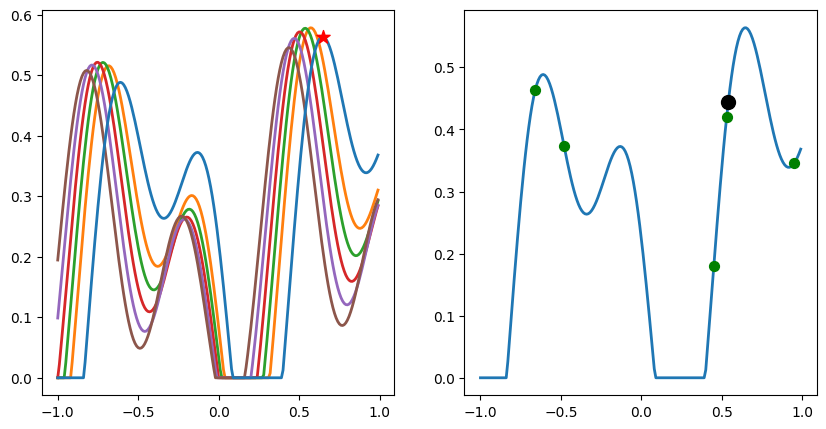

tensor([0.1814, 0.2317, 0.1685, 0.1338, 0.1442, 0.1403])
Iteration 4/20, Current best: 0.5342, 


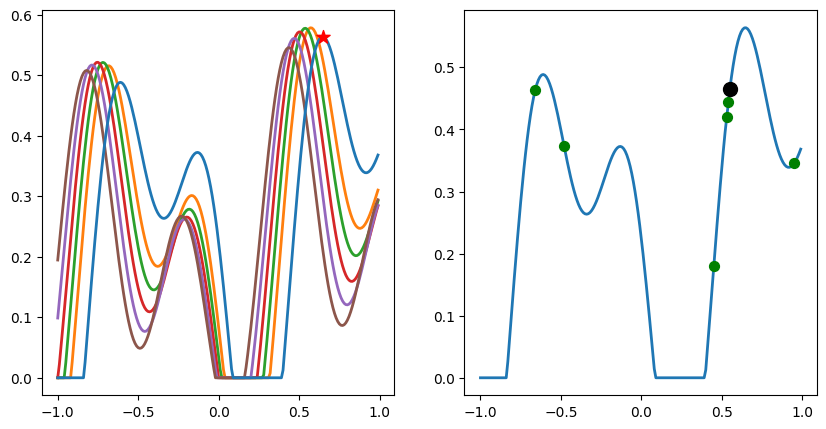

tensor([0.1790, 0.2205, 0.1559, 0.1307, 0.1376, 0.1763])
Iteration 5/20, Current best: 0.5146, 


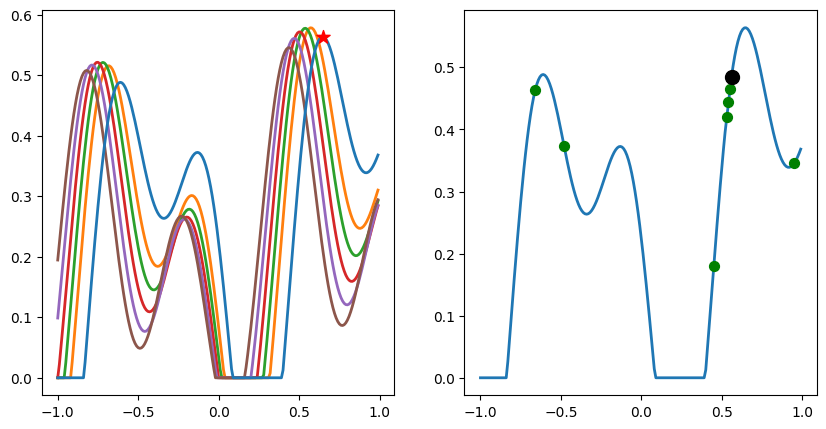

tensor([0.1892, 0.2190, 0.1636, 0.1352, 0.1300, 0.1629])
Iteration 6/20, Current best: 0.4385, 


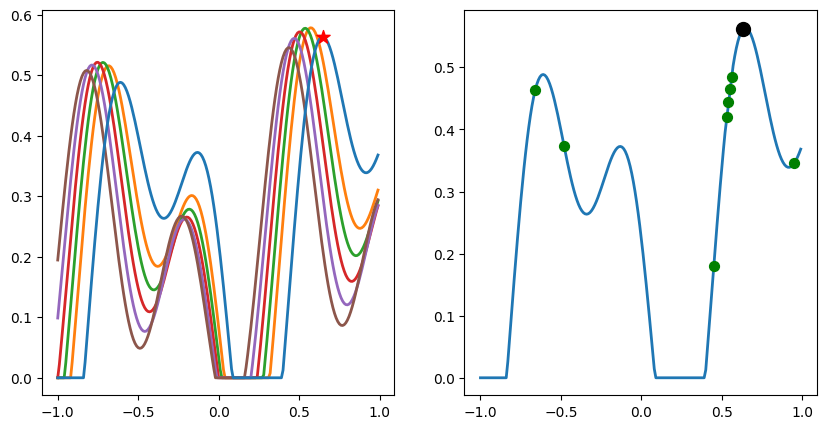

tensor([0.1973, 0.2095, 0.1593, 0.1390, 0.1372, 0.1578])
Iteration 7/20, Current best: 0.4385, 


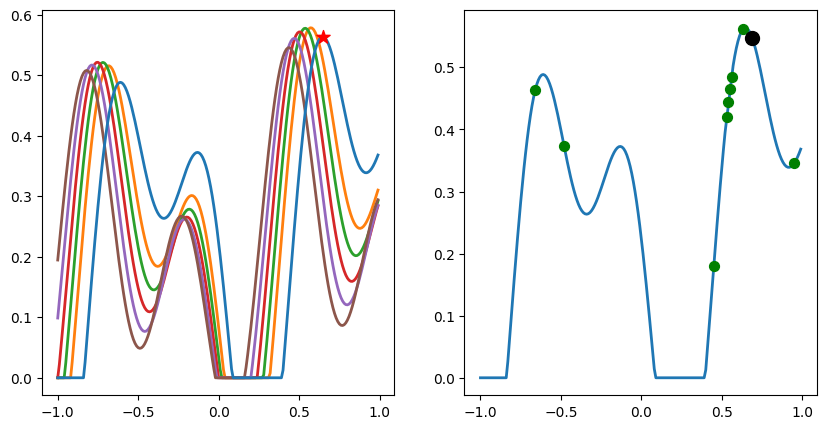

tensor([0.2503, 0.2272, 0.1695, 0.1429, 0.1364, 0.0737])
Iteration 8/20, Current best: 0.4385, 


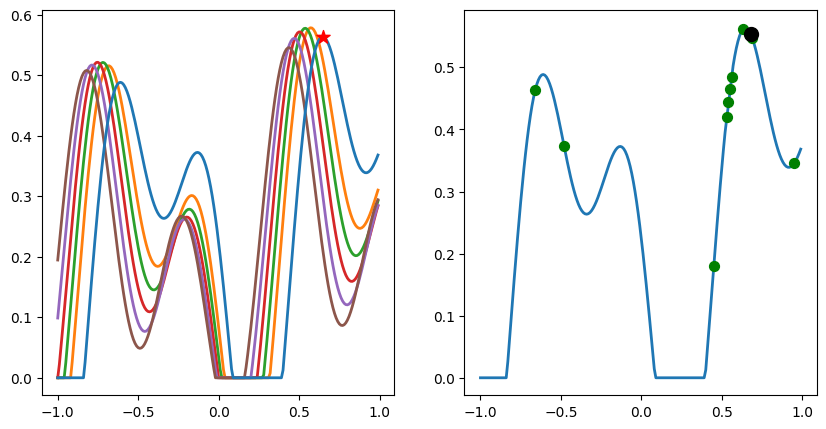

tensor([0.2731, 0.2385, 0.1650, 0.1505, 0.1334, 0.0395])
Iteration 9/20, Current best: 0.4385, 


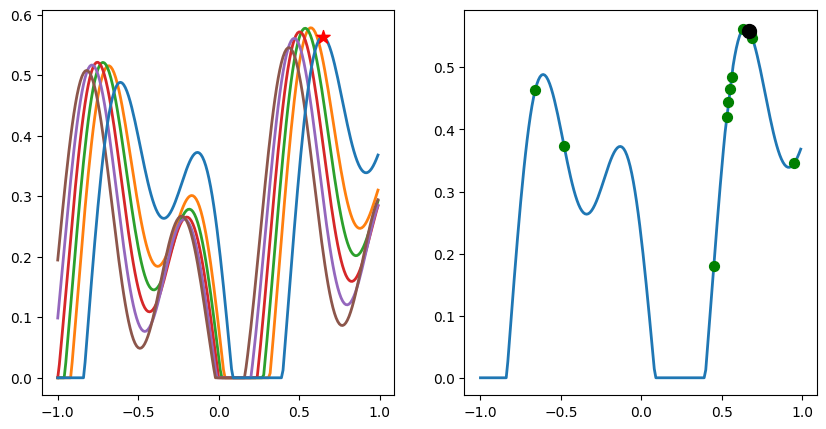

tensor([0.2874, 0.2441, 0.1789, 0.1551, 0.1101, 0.0245])
Iteration 10/20, Current best: 0.4379, 


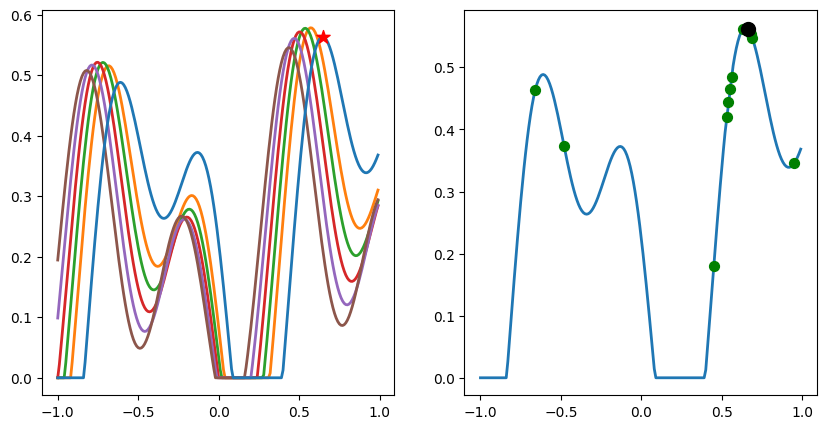

tensor([0.2871, 0.2561, 0.1811, 0.1631, 0.0954, 0.0171])
Iteration 11/20, Current best: 0.4379, 


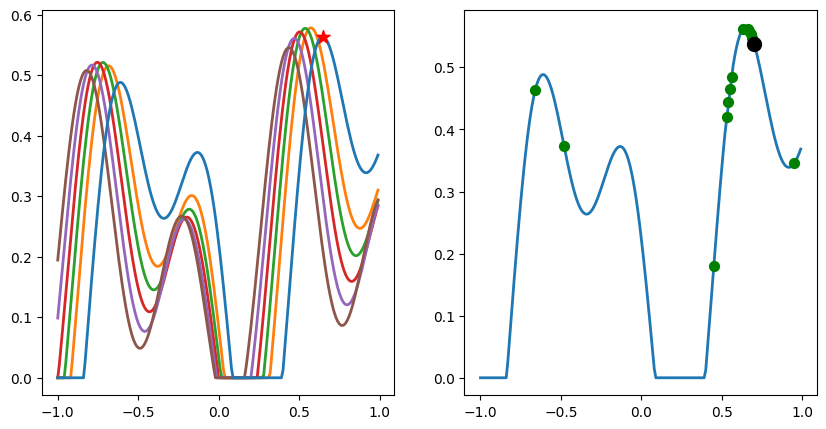

tensor([0.2929, 0.2591, 0.1968, 0.1656, 0.0764, 0.0092])
Iteration 12/20, Current best: 0.4361, 


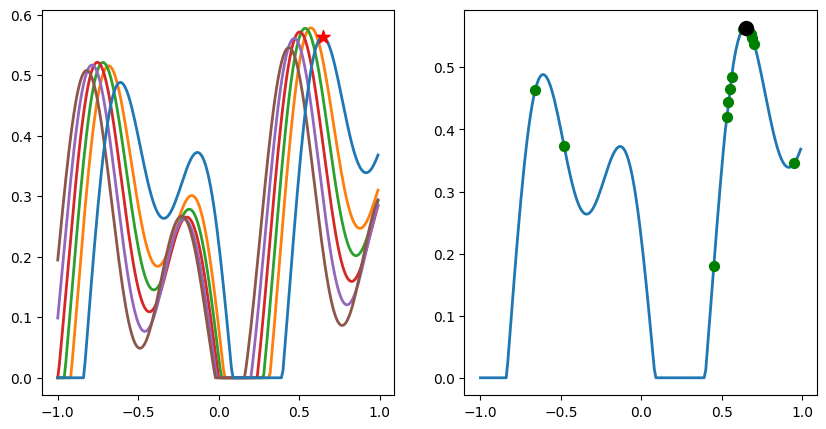

In [5]:
test_seed = "test1"
task_id = 8  # Task ID for the SimpleSynth benchmark
max_evaluations = 20

benchmark = SimpleSynth(seed=test_seed, start_task=task_id, initializations=3)


fontsize = 18
lw=2

import pfns4bo
from mpfns4bo.mpfns4bo import MPFNs4BO
meta_data = benchmark.get_meta_data()
optimizer = MPFNs4BO(torch.load( pfns4bo.hebo_plus_model), benchmark.search_space, meta_data, apply_power_transform=False,
                      only_obs_incumbents=True, tranformation_type=None, mixing_strategy="my",)




X = np.asarray(benchmark.benchmark_data["X"])
y = np.asarray(benchmark.benchmark_data["y"])
y = 1 - y

data_size = len(X)
# indices of pending evaluations
pending_evaluations = list(range(data_size))
current_evaluations = []

init_ids = benchmark.bo_initializations[test_seed]
for i in range(len(init_ids)):
    idx = init_ids[i]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)


min_regret_history = [np.min(y[current_evaluations])]
opt_time = []
for iteration in range(max_evaluations):
    fig, axs = plt.subplots(1,2, figsize=(10,5))

    
    not_init = np.setdiff1d(np.arange(data_size), init_ids)
    axs[0].plot(X[not_init], 1 - y[not_init], linewidth=lw, label="\textbf{Down Stream Task}", zorder = 99)

    task_names = ["Meta-Train Task 1", "Meta-Train Task 2", "Meta-Train Task 3", "Meta-Train Task 4", "Meta-Train Task 5"]

    for i, (k, mdata) in enumerate(meta_data.items()):
        mX = np.array([benchmark.search_space.to_numerical(e.configuration) for e in mdata])
        mY = - np.array([e.objectives["loss"] for e in mdata]).reshape(-1) # return to maximization (performance)
        sort_idx = np.argsort(mX.flatten())
        axs[0].plot(mX[sort_idx], mY[sort_idx], linewidth=lw, label=task_names[i])


    axs[0].scatter([X[y.argmin()]], [1 - y.min()], marker="*", s=100, c= "red", zorder = 99)

    not_evaluated = np.setdiff1d(np.arange(data_size), current_evaluations)
    axs[1].plot(X[not_evaluated], 1 - y[not_evaluated], linewidth=lw, label="\textbf{Down Stream Task}", zorder = 99)
    axs[1].scatter(X[current_evaluations], 1 - y[current_evaluations], s= 50, c= "green", label="Observed Samples", zorder = 99)
    idx = optimizer.observe_and_suggest(
        X[current_evaluations], y[current_evaluations], X[pending_evaluations]
    )

    axs[1].scatter(X[pending_evaluations][idx], 1 - y[pending_evaluations][idx], s= 100, c= "black", label="Next Sample (with meta learning)", zorder = 99)
    idx = pending_evaluations[idx]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)
    min_regret_history.append(np.min(y[current_evaluations]))

    print(optimizer.pfnimputation.reliability_scores)

    print(f"Iteration {iteration + 1}/{max_evaluations}, "
            f"Current best: {min_regret_history[-1]:.4f}, ")

    plt.show()


    if min(y) in min_regret_history:
        break

# negate to recover accuracy
min_regret_history += [min(y).item()] * (max_evaluations - i - 1)